<a href="https://colab.research.google.com/github/ga4gh/analytics-dashboard/blob/develop/notebooks/Analytics_Dashboard_WIP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analytics Dashboard

This notebook provides a proof of concept for a comprehensive analytics dashboard for exploring GA4GH initiatives.

### **What This Notebook Does**

This notebook automatically:
1. **Fetches**
     * GitHub repositories
     * PyPi libraries
     * Pubmed articles
2. **Analyzes the data** to show trends, statistics, and insights
3. **Creates interactive visualizations** to graphically present trends in the data

### **How to Run This Notebook**

1. **Click "Run All" in your Jupyter environment** - Everything will run automatically
2. **Wait for results** - The notebook will fetch data and create visualizations
3. **Scroll through the results** - Each section provides different insights

### **What You Can Customize**

### **Advanced Changes**
- Requires knowledge of Plotly and Dash libraries
- Can modify visualization types, styling, and data presented

### **What You'll See**

1. **Yearly Productivity** - A chart of repositories, articles and libraries created every year since the inception of GA4GH
   
### **Important Notes**

- **Processing time** - Initial run may take 2-3 minutes
- **Internet required** - Fetches data from API set up by the tech team
- **No data storage** - Results are temporary unless you save them

###** Troubleshooting**

**If visualizations don't appear:**
1. Ensure you have the required libraries installed
2. Try refreshing your browser
3. Check that JavaScript is enabled

**If results seem incomplete:**  
***Note: This is not a complete dataset. This is a POC and will be more complete in the future***
1. Try running individual sections instead of all at once


### **Libraries Used in This Notebook**

**dash** → Used to build interactive dashboard components such as graphs, layouts, and user inputs directly inside the notebook.

**requests** → Connects to the Analytics Dashboard DB which is curated by the Tech Team and retrieves data in JSON format.

**pandas** → Helps convert API responses into DataFrames for easy filtering, analysis, and visualization.

**json** → Used for handling and inspecting raw JSON responses.

**typing (List, Optional, Dict, Any)** → Adds optional type hints to improve code readability and maintainability.

**plotly.express** → Creates interactive charts (bar, line, pie, scatter) quickly and easily.

In [6]:
# Make sure Dash is installed
!pip install dash

In [7]:
# Some of the imports required to use the notebook
import requests
import json
import dash
from typing import List, Optional, Dict, Any
from dash import Dash, dcc, html, Input, Output, callback, dash_table, jupyter_dash
from dash.dependencies import Input, Output
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
from collections import Counter
from datetime import datetime


## **Configurations & API Setup**
---
**Explanation:**
- There are several endpoints for the Analytics Dashboard using the ```BASE_URL``` such as the ```TOTAL_PACKAGES_ENDPOINT``` as well as others listed in the cell below.
- ```get_repos(REPO_ENDPOINT, repos_list)```: This function will retrieve all the repos under the "ga4gh" org from the DB
  1. Makes a GET request to the specified endpoint.  
  2. Raises an error if the request fails.  
  3. Returns the response as JSON for further processing.

---

**Data Exploration:**  
- You can test this by running, for example:  
  ```python
  get_json(PM_KEYWORD)

In [8]:
# -----------------------------------------------------
# The setup section
# -----------------------------------------------------

# Base URL
BASE_URL = "http://analytics-staging.ga4gh.org:8000"

# Github Endpoints
REPO_ENDPOINT = f"{BASE_URL}/github/name/"
repos_list = ['ga4gh-schemas', 'ga4gh-server', 'compliance', 'dwg-website', 'gastore', 'mme-apis', 'metadata-team', 'g2p-team', 'benchmarking-tools', 'build', 'tool-registry-service-schemas', 'swg-ssig', 'tool-registry-server', 'workflow-execution-server', 'task-execution-server', 'task-execution-schemas', 'workflow-execution-service-schemas', 'ga4gh-consent-policy', 'hgvs-lib', 'tool-registry-validator', 'tool-registry-reference-implementation', 'vrs', 'hackathon2016', 'ga4gh-client', 'ga4gh-common', 'htsget', 'data-repository-service-schemas', 'ga4gh-converters', 'ADA-M', 'wiki', 'vrs-python', 'cloud-interop-testing', 'phenopacket-schema', 'large-scale-genomics-wiki', 'refget-compliance-suite', 'va-spec', 'variant-representation', 'approval-tracker', 'duri', 'refget-client', 'cloud-conformance-testing', 'data-object-service-schemas', 'w3id.org', 'data-security', 'pedigree', 'gh-openapi-docs', 'ga4gh-drs-client', 'refget-cloud', 'htsget-refserver', 'refget-loader', 'cloud-interop-ui', 'ga4gh-copyright-policy', 'TASC', 'standards-schema', 'htsget-compliance', 'ga4gh-registry', 'gatk', 'refget-compliance', 'htsjdk', 'ga4gh-bed', 'fasp-scripts', 'htsget-refserver-utils', 'ga4gh-ci', 'refget', 'reverse-lookup-spec', 'ga4gh-starter-kit-drs', 'vrs-vcf-alignment', 'pedigree-fhir-ig', 'vrsatile', 'ga4gh-starter-kit-docs', 'ga4gh-starter-kit-common', 'ga4gh-starter-kit-passport-broker', 'pedigree_family_history_terminology', 'ga4gh-starter-kit-wes', 'ga4gh-starter-kit', 'ga4gh-starter-kit-ui', 'machine-readable-consent-guidance', 'pedigree-tools', 'vrs-protobuf', 'ga4gh-starter-kit-utils', 'vrsatile-pydantic', 'ga4gh-testbed-lib', 'ga4gh-starter-kit-refget', 'ga4gh-testbed-ui', 'pedigree-validator', 'gks-metaschema', 'future-of-vcf', 'ga4gh-starter-kit-data-connect', 'cloud-best-practices', 'schema-registry-api', 'schema-registry-ui', 'schema-registry', 'tech-team', 'ga4gh-testbed-api', 'vrs-hackathons', 'Get-Started-with-GA4GH-APIs', 'ga4gh-starter-kit-passport-ui', 'vrs-phenopackets', 'cohort-rep-hackathon', 'product-process', 'openapi-test-runner', 'drs-compliance-suite', 'vrs-clojure', 'fasp-clients', 'sa-spec', 'gk-pilot', 'ga4gh-starter-kit-beacon', 'quality-control-wgs', 'Strategic-Refresh', 'drs-test-a-thon', 'experiments-metadata', 'ga4gh-pgx', 'compliance-tests-ga4gh-tes', 'ga4gh-crypt4gh', 'compliance-tests-ga4gh-wes', 'ga4gh-doi', 'gks-core', 'cat-vrs', 'compliance-tests-ga4gh-service-registry', 'ga4gh-testbed-api-aws-stack', 'gks2clinvar', 'human-pangenome-project', 'gks-validator', 'gks-portal', 'cat-vrs-python', 'va-spec-python', 'Website-flowcharts', 'gks-starter-repo']

# PyPi Endpoints
TOTAL_PACKAGES_ENDPOINT = f"{BASE_URL}/pypi/total-packages"
PACKAGE_VERSIONS_ENDPOINT = f"{BASE_URL}/pypi/package-versions"
RELEASES_OVER_YEARS_ENDPOINT = f"{BASE_URL}/pypi/releases-over-years"
PYPI_DETAILS_ENDPOINT = f"{BASE_URL}/pypi/project-details"
FIRST_RELEASES_ENDPOINT = f"{BASE_URL}/pypi/first-releases"
ALL_PACKAGES_ENDPOINT = f"{BASE_URL}/pypi/all-packages"

# PubMed Endpoints
PM_KEYWORD = f"{BASE_URL}/pubmed/articles/GA4GH"

# Function that will take a list of repos and retrieve them from the DB
def get_repos(endpoint: str, list_of_repos: List[str]) -> List[Dict[str, Any]]:

    items: List[Dict[str, Any]] = []
    url = endpoint

    for repo in list_of_repos:
        resp = requests.get(url + repo)
        resp.raise_for_status()
        items.append(resp.json()[0])

    return items

# Function to make a request to the endpoints to return data from the DB addressing any pagination issues
def get_json(endpoint: str, token: Optional[str] = None, per_page: int = 100) -> List[Dict[str, Any]]:

    headers = {}
    if token:
        headers["Authorization"] = f"token {token}"

    params = {"per_page": per_page, "page": 1}
    items: List[Dict[str, Any]] = []
    url = endpoint

    while True:
        resp = requests.get(url, headers=headers, params=params, timeout=30)
        resp.raise_for_status()
        data = resp.json()

        if not isinstance(data, list):
            return data

        items.extend(data)

        if "next" in resp.links:
            url = resp.links["next"]["url"]
            params = None
        else:
            break

    return items

# **PyPi**
### **Dynamic DataTable**

This section creates a dynamic data table that displays the PyPi libraries relating to GA4GH products.  
The chart shows the **number of versions for each package** currently displayed in the table.

**How to Use the Interactive Table


1.   **Search:** Type in the search box to instantly filter the rows.

2.   **Sort Columns:** Click any column header to sort the table up or down.

3.   **Pagination:** Use the page buttons at the bottom to move through the data.

4.   **Rows per Page:** Choose how many rows to display at once from the dropdown menu.

5.   **Horizontal Scroll:** If the table is

```
# This is formatted as code
```

 wide, scroll sideways to see all columns.

In [37]:
# -----------------------------------------------------
# 1. Total packages
# -----------------------------------------------------
total_packages_resp = get_json(TOTAL_PACKAGES_ENDPOINT)
total_packages = int(total_packages_resp.get("total_packages", 0))

# -----------------------------------------------------
# 2. Project details
# -----------------------------------------------------
details_data = get_json(PYPI_DETAILS_ENDPOINT)

# Build DataFrame
rows = []
for pkg in details_data:
    versions_list = pkg.get("versions", [])
    versions_count = versions_list[0].get("versions", 0) if versions_list else 0
    rows.append({
        "project_name": pkg.get("project_name"),
        "description": pkg.get("description"),
        "author_name": pkg.get("author_name"),
        "author_email": pkg.get("author_email"),
        "category": pkg.get("category"),
        "versions_count": versions_count,
    })

df = pd.DataFrame(rows)

# -----------------------------------------------------
# 3. Dynamic DataTable
# -----------------------------------------------------
from IPython.display import display, HTML
total_packages = len(df)
# Convert DataFrame to HTML with DataTables
html_str = df.to_html(classes="display", table_id="my_table", index=False)
html_template = f"""
<h3>Total PyPI Packages: {total_packages}</h3>
{html_str}
<link rel="stylesheet" type="text/css" href="https://cdn.datatables.net/1.13.6/css/jquery.dataTables.css">
<script type="text/javascript" charset="utf8" src="https://code.jquery.com/jquery-3.7.1.js"></script>
<script type="text/javascript" charset="utf8" src="https://cdn.datatables.net/1.13.6/js/jquery.dataTables.js"></script>
<script>
$(document).ready(function() {{
    $('#my_table').DataTable({{
        "pageLength": 10,
        "lengthMenu": [5, 10, 20, 50],
        "order": [[0, "asc"]],
        "searching": true,
        "info": true,
        "paging": true
    }});
}});
</script>
"""
# Display inline in notebook
display(HTML(html_template))


HTTPError: 404 Client Error: Not Found for url: http://analytics-staging.ga4gh.org:8000/pypi/project-details?per_page=100&page=1

### **Bar Graph**

This section creates a bar graph based on the data in the table above.

### **Key Features:**
- **Hover Tooltips** → Show extra information such as project name, category, and version count when hovering over the bar.  
- **Custom Styling** → Titles, colors, and hover formatting.

### **Exploration Opportunities for Users:**
- **Change the chart type** → Replace `"type": "bar"` with `"type": "scatter"` for a line chart.  
- **Adjust hover text** → Customize what appears on hover by editing the `hover_texts` list.  
- **Change colors** → Update `"marker": {"color": "#2E86C1"}` to another hex code (e.g., `"#E74C3C"` for red).
- **Modify axis titles** -> In `xaxis` and `yaxis`, replace `"project_name"` or `"versions_count"` with friendlier labels.

This visualization gives a **clear snapshot of version counts** for the subset of packages currently being inspected in the table.

In [10]:
# -----------------------------------------------------
# 4. Bar graph (Logic adapted from update_bar)
# -----------------------------------------------------
# Mimicking the "Page 1" logic from the original app (first 10 rows)
page_data = df.iloc[0:10]

# Create hover text: shorten long description
hover_texts = [
    f"<b>{row['project_name']}</b><br>"
    f"Category: {row.get('category', '')}<br>"
    f"Versions: {str(row.get('versions_count', ''))}"
    for _, row in page_data.iterrows()
]

fig_bar = go.Figure(data=[
    go.Bar(
        x=page_data["project_name"],      # X-axis: package names
        y=page_data["versions_count"],    # Y-axis: version counts
        marker={"color": "#2E86C1"},      # Bar color
        hovertext=hover_texts,            # Custom hover info
        hoverinfo="text"                  # Only show hover text
    )
])

fig_bar.update_layout(
    title={
        "text": "Package Versions Count (Top 10 Preview)",
        "x": 0.5,          # center title
        "xanchor": "center",
        "yanchor": "top",
        "font": {"size": 20, "color": "#2C3E50"}
    },
    xaxis={"title": "project_name", "tickangle": -45},
    yaxis={"title": "versions_count"},
    plot_bgcolor="#f9f9f9",
    paper_bgcolor="#ffffff",
    margin={"b": 120}
)

NameError: name 'df' is not defined

### **Pie Graph**
This pie graph is based on the data table above displaying the categories of the PyPi libraries from implementations, references and standards.

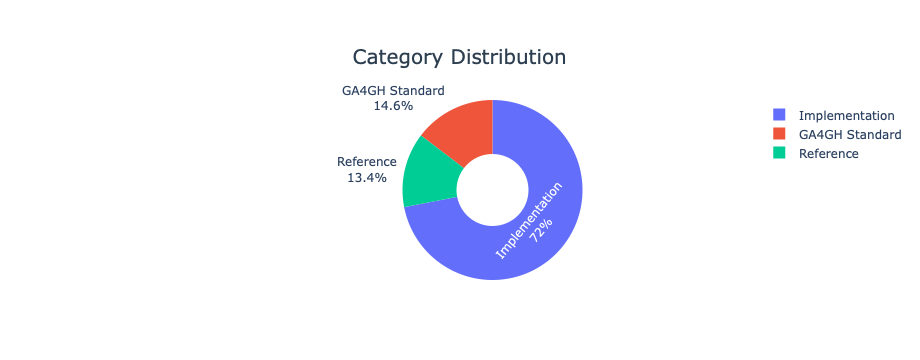

In [ ]:
# -----------------------------------------------------
# 5. Category distribution (Logic adapted from update_category_distribution)
# -----------------------------------------------------
# Count categories
cat_counts = df["category"].value_counts().reset_index()
cat_counts.columns = ["category", "count"]

fig_pie = go.Figure(data=[
    go.Pie(
        labels=cat_counts["category"],
        values=cat_counts["count"],
        hole=0.4,
        textinfo="label+percent",
        hoverinfo="label+value+percent"
    )
])

fig_pie.update_layout(
    title={
        "text": "Category Distribution",
        "x": 0.5,          # center title
        "xanchor": "center",
        "yanchor": "top",
        "font": {"size": 20, "color": "#2C3E50"}
    },
    plot_bgcolor="#f9f9f9",
    paper_bgcolor="#ffffff"
)


# **GitHub**
### **Recent Update Dates for Github and PubMed**

This line graph presents year-by-year update counts for PubMed articles versus GitHub repositories; hover over the points to view the updated repository and article totals as well as a list of articles and repositories.


In [11]:
# 1. Process GitHub Data
GA4GH_repos = get_repos(REPO_ENDPOINT, repos_list)
gh_names = [repo['name'] for repo in GA4GH_repos]
gh_dates = [repo['pushed_at'] for repo in GA4GH_repos]

df_gh = pd.DataFrame({
    "item": gh_names,
    "created_at": pd.to_datetime(gh_dates, utc=True)
})
df_gh["Source"] = "GitHub Repos"

# 2. Process PubMed Data
pubmed_releases = get_json(PM_KEYWORD)
pm_names = [release['title'] for release in pubmed_releases]
pm_dates = [release['publish_date'] for release in pubmed_releases]

df_pm = pd.DataFrame({
    "item": pm_names,
    "created_at": pd.to_datetime(pm_dates, utc=True, errors='coerce')
})
df_pm["Source"] = "PubMed Articles"

# 3. Combine GitHub and PubMed
df_raw = pd.concat([df_gh, df_pm])
df_raw = df_raw.dropna(subset=["created_at"])
df_raw["year"] = df_raw["created_at"].dt.year

# Group by Year and Source
final_df = df_raw.groupby(["year", "Source"]).agg({"item": list}).reset_index()
final_df["yearly_count"] = final_df["item"].apply(len)
final_df["items_str"] = final_df["item"].apply(lambda items: "<br>".join(items))

# Sort values
final_df = final_df.sort_values(["Source", "year"])

# 4. Create Graph
fig2 = px.line(
    final_df,
    x="year",
    y="yearly_count",
    color="Source",
    markers=True,
    title="Most Recent Update: GitHub & PubMed",
    labels={"year": "Year", "yearly_count": "Updates per Year"},
    custom_data=["items_str", "Source"]
)

# 5. Update Hover Template
fig2.update_traces(
    hovertemplate=(
        "<b>%{customdata[1]}</b><br>" # Source Name
        "Year: %{x}<br>"
        "Updates: %{y}<br><br>"
        "<b>Updated Items:</b><br>%{customdata[0]}<extra></extra>"
    ),
    marker=dict(size=8),
)

fig2.update_layout(
    xaxis_title="Year",
    yaxis_title="Updates per Year",
    margin=dict(l=40, r=20, t=70, b=120),
    height=500,
    legend_title_text=""
)


In [20]:
pm_df = pd.DataFrame.from_records(pubmed_releases)
pm_df['publish_date'] = pd.to_datetime(pm_df['publish_date'], utc=True, errors='raise')
pm_df['year'] = pm_df['publish_date'].dt.year
pm_df.head()


,id,record_id,title,abstract,journal,source_id,doi,status,publish_date,link,authors,created_at,created_by,updated_at,updated_by,deleted_at,deleted_by,version,year
0,143,384,[Rare-disease data standards],None,Bundesgesundheitsblatt Gesundheitsforschung Ge...,36149471,10.1007/s00103-022-03591-2,Published,2023-11-09 00:00:00+00:00,https://pubmed.ncbi.nlm.nih.gov/36149471,[],2025-12-03T13:04:52,Dash,2025-12-03T13:04:52,Dash,None,None,1,2023
1,144,385,The Human Phenotype Ontology in 2024: phenotyp...,None,Nucleic Acids Res,37953324,10.1093/nar/gkad1005,Published,2023-12-11 00:00:00+00:00,https://pubmed.ncbi.nlm.nih.gov/37953324,[],2025-12-03T13:04:52,Dash,2025-12-03T13:04:52,Dash,None,None,1,2023
2,145,386,GA4GH Phenopackets: A Practical Introduction,None,Adv Genet (Hoboken),36910590,10.1002/ggn2.202200016,Published,2024-01-03 00:00:00+00:00,https://pubmed.ncbi.nlm.nih.gov/36910590,[],2025-12-03T13:04:52,Dash,2025-12-03T13:04:52,Dash,None,None,1,2024
3,146,387,The Genomic Commons,None,Annu Rev Genomics Hum Genet,29400986,10.1146/annurev-genom-083117-021552,Published,2018-06-02 00:00:00+00:00,https://pubmed.ncbi.nlm.nih.gov/29400986,[],2025-12-03T13:04:52,Dash,2025-12-03T13:04:52,Dash,None,None,1,2018
4,147,388,"Equity, diversity, and inclusion at the Global...",None,Cell Genom,37868041,10.1016/j.xgen.2023.100386,Published,2024-11-10 00:00:00+00:00,https://pubmed.ncbi.nlm.nih.gov/37868041,[],2025-12-03T13:04:52,Dash,2025-12-03T13:04:52,Dash,None,None,1,2024


In [25]:
gh_df = pd.DataFrame.from_records(GA4GH_repos)

gh_df['last_updated'] = pd.to_datetime(gh_df['last_updated'], utc=True, errors='raise')
gh_df['pushed_at'] = pd.to_datetime(gh_df['pushed_at'], utc=True, errors='raise')

gh_df.head()

,id,record_id,name,repo_link,owner,description,is_fork,last_updated,pushed_at,is_archived,...,forks_count,open_issues_count,network_count,subscribers_count,branches_count,created_at,created_by,updated_at,updated_by,version
0,1001,1001,ga4gh-schemas,https://github.com/ga4gh/ga4gh-schemas,ga4gh,Models and APIs for Genomic data. RETIRED 2018...,False,2025-08-27 19:50:32+00:00,2022-10-28 02:53:52+00:00,True,...,112,161,112,99,22,2025-09-30T20:05:17.148000Z,Chen,2025-09-30T20:05:17.148000Z,Chen,1
1,1002,1002,ga4gh-server,https://github.com/ga4gh/ga4gh-server,ga4gh,Reference implementation of the APIs defined i...,False,2025-02-05 17:19:25+00:00,2018-01-24 10:57:37+00:00,True,...,91,154,91,51,15,2025-09-30T20:05:17.158000Z,Chen,2025-09-30T20:05:17.158000Z,Chen,1
2,1003,1003,compliance,https://github.com/ga4gh/compliance,ga4gh,Compliance test suite for the APIs defined in ...,False,2023-01-28 21:13:03+00:00,2018-01-24 11:00:30+00:00,True,...,23,37,23,32,8,2025-09-30T20:05:17.163000Z,Chen,2025-09-30T20:05:17.163000Z,Chen,1
3,1004,1004,dwg-website,https://github.com/ga4gh/dwg-website,ga4gh,GA4GH Data Working Group website hosted at ga4...,False,2017-02-18 18:53:58+00:00,2016-03-15 17:04:00+00:00,False,...,8,4,8,10,1,2025-09-30T20:05:17.169000Z,Chen,2025-09-30T20:05:17.169000Z,Chen,1
4,1005,1005,gastore,https://github.com/ga4gh/gastore,ga4gh,Sample code to inform a discussion around cont...,False,2023-01-28 18:25:16+00:00,2015-04-08 20:00:19+00:00,True,...,3,2,3,36,1,2025-09-30T20:05:17.175000Z,Chen,2025-09-30T20:05:17.175000Z,Chen,1


In [39]:
fetch_date = '2025-10-01'
target_date = pd.to_datetime(fetch_date, utc=True)

gh_df['days_since_pushed_at'] = (target_date - gh_df['pushed_at']).dt.days
gh_df['days_since_last_updated'] = (target_date - gh_df['last_updated']).dt.days

gh_df['activity_score'] = 1/(1+gh_df['days_since_pushed_at'])+1/(1+gh_df['days_since_last_updated'])

In [36]:
import numpy as np

conditions = [
    (gh_df['is_archived'] == False) & (gh_df['days_since_pushed_at'] < 180),
    (gh_df['is_archived'] == False) & (gh_df['days_since_pushed_at'] >= 180) & (gh_df['days_since_pushed_at'] <= 365),
    (gh_df['is_archived'] == False) & (gh_df['days_since_pushed_at'] > 365),
    (gh_df['is_archived'] == True)
]
choices = ['Active', 'Low Activity', 'Inactive', 'Archived']

gh_df['activity_status'] = np.select(conditions, choices, default='Unknown')

display(gh_df[['name', 'is_archived', 'days_since_pushed_at', 'activity_status']])

gh_df['activity_status'].value_counts()

,name,is_archived,days_since_pushed_at,activity_status
0,ga4gh-schemas,True,1099,Archived
1,ga4gh-server,True,2837,Archived
2,compliance,True,2837,Archived
3,dwg-website,False,3517,Inactive
4,gastore,True,3859,Archived
...,...,...,...,...
123,gks-portal,False,65,Active
124,cat-vrs-python,False,35,Active
125,va-spec-python,False,35,Active
126,Website-flowcharts,False,283,Low Activity


,count
activity_status,
Inactive,80
Active,25
Archived,13
Low Activity,10


In [33]:
gh_df['engagement_score'] = gh_df['stargazers_count'] + gh_df['watchers_count'] + gh_df['subscribers_count']

In [32]:
list(gh_df)

['id',
 'record_id',
 'name',
 'repo_link',
 'owner',
 'description',
 'is_fork',
 'last_updated',
 'pushed_at',
 'is_archived',
 'license',
 'stargazers_count',
 'watchers_count',
 'forks_count',
 'open_issues_count',
 'network_count',
 'subscribers_count',
 'branches_count',
 'created_at',
 'created_by',
 'updated_at',
 'updated_by',
 'version',
 'days_since_pushed_at',
 'days_since_last_updated',
 'activity_score']

# **PubMed**
### **Top 8 Journals for GA4GH Articles**

This graph displays the top 8 Journals in PubMed for both "GA4GH" and "Global Alliance for Genomics and Health" keywords.

In [5]:
def get_articles_data(keyword):
    """
    Fetches article data from the API for a given keyword.

    What it does:
    - Sends a request to our analytics dashboard API
    - Returns a list of articles if successful
    - Returns an empty list if there's an error
    - Prints error messages to help with troubleshooting

    Parameters:
    - keyword: The search term (e.g., "GA4GH")

    Returns:
    - List of article dictionaries with all the metadata

    DO NOT MODIFY: This function is used throughout the analytics
    """
    url = f"{BASE_URL}/pubmed/articles/{keyword}"
    response = requests.get(url)

    if response.status_code == 200:
        return response.json()
    print(f"Error fetching data for {keyword}: {response.status_code}")
    return []

keywords = [
    "GA4GH",
    "Global Alliance for Genomics and Health"
]

all_articles_data = {}

for keyword in keywords:
    articles = get_articles_data(keyword)
    all_articles_data[keyword] = articles


In [6]:
merged_df = pd.DataFrame()
for k in keywords:
    merged_df = pd.concat( [merged_df, pd.DataFrame.from_dict(all_articles_data[k])],
                           ignore_index=True, sort=False)

In [7]:
list(merged_df)

['id',
 'record_id',
 'title',
 'abstract',
 'journal',
 'source_id',
 'doi',
 'status',
 'publish_date',
 'link',
 'authors',
 'created_at',
 'created_by',
 'updated_at',
 'updated_by',
 'deleted_at',
 'deleted_by',
 'version']

In [ ]:
merged_dedup_df = merged_df.drop_duplicates('title', keep='first')
merged_dedup_df.shape

(132, 18)

In [ ]:
merged_dedup_df['journal'].value_counts()

journal
Cell genomics                                                                          13
Bioinformatics (Oxford, England)                                                        9
Nucleic acids research                                                                  9
Human mutation                                                                          7
NPJ genomic medicine                                                                    5
F1000Research                                                                           5
BMC medical genomics                                                                    4
Human genomics                                                                          4
medRxiv : the preprint server for health sciences                                       4
GigaScience                                                                             3
European journal of human genetics : EJHG                                               3
Ge

In [ ]:
for j, df in merged_dedup_df.groupby('journal'):
    if (df.shape[0] > 1):
        print(j)
        for m,n in df.sort_values(by='doi').iterrows():
            print(n['doi'])
        print('')
        #print(df['title'])

Annual review of genomics and human genetics
10.1146/annurev-genom-083115-022515
10.1146/annurev-genom-083117-021552

Applied & translational genomics
10.1016/j.atg.2014.09.011
10.1016/j.atg.2016.01.005

BMC bioinformatics
10.1186/s12859-020-03926-3
10.1186/s12859-024-05993-2

BMC medical genomics
10.1186/s12920-017-0247-4
10.1186/s12920-017-0278-x
10.1186/s12920-017-0282-1
10.1186/s12920-019-0604-6

Bioinformatics (Oxford, England)
10.1093/bioinformatics/btab524
10.1093/bioinformatics/btac568
10.1093/bioinformatics/btad126
10.1093/bioinformatics/btae136
10.1093/bioinformatics/btaf079
10.1093/bioinformatics/btaf273
10.1093/bioinformatics/btaf546
10.1093/bioinformatics/bty269
10.1093/bioinformatics/bty492

Biopreservation and biobanking
10.1089/bio.2016.0005
10.1089/bio.2022.0042

Cell genomics
10.1016/j.xgen.2021.100027
10.1016/j.xgen.2021.100028
10.1016/j.xgen.2021.100029
10.1016/j.xgen.2021.100030
10.1016/j.xgen.2021.100031
10.1016/j.xgen.2021.100032
10.1016/j.xgen.2021.100033
10.101

In [ ]:
merged_dedup_df[(merged_dedup_df['journal'] == 'Cell genomics')].sort_values(by=['title'])

,id,record_id,title,abstract,journal,source_id,doi,status,publish_date,link,authors,created_at,created_by,updated_at,updated_by,deleted_at,deleted_by,version
64,109,330,Aligning NIH's existing data use restrictions ...,It is widely accepted that large-scale genomic...,Cell genomics,37719151,10.1016/j.xgen.2023.100381,Published,2023-08-18T00:00:00,https://pubmed.ncbi.nlm.nih.gov/37719151/,"[{'id': 2461, 'article_id': 109, 'name': 'Jona...",2025-10-07T15:28:44.080301,deeptha,2025-10-07T15:28:44.080301,deeptha,None,None,1
38,47,268,CanDIG: Federated network across Canada for mu...,We present the Canadian Distributed Infrastruc...,Cell genomics,36778585,10.1016/j.xgen.2021.100033,Published,2021-11-10T00:00:00,https://pubmed.ncbi.nlm.nih.gov/36778585/,"[{'id': 864, 'article_id': 47, 'name': 'L Jona...",2025-10-07T15:25:05.754309,demo_user,2025-10-07T15:25:05.754309,demo_user,None,None,1
72,118,339,Empirical validation of an automated approach ...,The current paradigm for data use oversight of...,Cell genomics,36778584,10.1016/j.xgen.2021.100031,Published,2021-11-10T00:00:00,https://pubmed.ncbi.nlm.nih.gov/36778584/,"[{'id': 2622, 'article_id': 118, 'name': 'Mora...",2025-10-07T15:28:44.081377,deeptha,2025-10-07T15:28:44.081378,deeptha,None,None,1
15,24,245,"Equity, diversity, and inclusion at the Global...",A lack of diversity in genomics for health con...,Cell genomics,37868041,10.1016/j.xgen.2023.100386,Published,2023-08-24T00:00:00,https://pubmed.ncbi.nlm.nih.gov/37868041/,"[{'id': 359, 'article_id': 24, 'name': 'Neerja...",2025-10-07T15:25:05.753331,demo_user,2025-10-07T15:25:05.753332,demo_user,None,None,1
30,38,259,Federated analysis of BRCA1 and BRCA2 variatio...,More than 40% of the germline variants in Clin...,Cell genomics,35373174,10.1016/j.xgen.2022.100109,Published,2022-03-09T00:00:00,https://pubmed.ncbi.nlm.nih.gov/35373174/,"[{'id': 511, 'article_id': 38, 'name': 'James ...",2025-10-07T15:25:05.754003,demo_user,2025-10-07T15:25:05.754004,demo_user,None,None,1
35,43,264,GA4GH Passport standard for digital identity a...,The Global Alliance for Genomics and Health (G...,Cell genomics,34820660,10.1016/j.xgen.2021.100030,Published,2021-11-10T00:00:00,https://pubmed.ncbi.nlm.nih.gov/34820660/,"[{'id': 780, 'article_id': 43, 'name': 'Craig ...",2025-10-07T15:25:05.754154,demo_user,2025-10-07T15:25:05.754155,demo_user,None,None,1
34,42,263,GA4GH: International policies and standards fo...,The Global Alliance for Genomics and Health (G...,Cell genomics,35072136,10.1016/j.xgen.2021.100029,Published,2021-11-10T00:00:00,https://pubmed.ncbi.nlm.nih.gov/35072136/,"[{'id': 578, 'article_id': 42, 'name': 'Heidi ...",2025-10-07T15:25:05.754122,demo_user,2025-10-07T15:25:05.754123,demo_user,None,None,1
71,117,338,I can drive in Iceland: Enabling international...,"In this issue of , GA4GH reports key efforts t...",Cell genomics,36778587,10.1016/j.xgen.2021.100034,Published,2021-11-10T00:00:00,https://pubmed.ncbi.nlm.nih.gov/36778587/,"[{'id': 2620, 'article_id': 117, 'name': 'Chri...",2025-10-07T15:28:44.081318,deeptha,2025-10-07T15:28:44.081318,deeptha,None,None,1
63,115,336,International federation of genomic medicine d...,We promote a shared vision and guide for how a...,Cell genomics,35128509,10.1016/j.xgen.2021.100032,Published,2021-11-10T00:00:00,https://pubmed.ncbi.nlm.nih.gov/35128509/,"[{'id': 2570, 'article_id': 115, 'name': 'Adri...",2025-10-07T15:28:44.081156,deeptha,2025-10-07T15:28:44.081157,deeptha,None,None,1
0,1,222,Remote visualization of large-scale genomic al...,The Solve-RD project objectives include solvin...,Cell genomics,36819661,10.1016/j.xgen.2022.100246,Published,2023-01-11T00:00:00,https://pubmed.ncbi.nlm.nih.gov/36819661/,"[{'id': 1, 'article_id': 1, 'name': 'Alberto C...",2025-10-07T15:20:46.389778,deeptha,2025-10-07T15:20:46.389780,deeptha,None,None,1


In [ ]:
merged_dedup_df.loc[:,'datetime'] = pd.to_datetime(merged_dedup_df['publish_date'], utc=True, errors='raise')

In [ ]:
pm_year_count = pd.DataFrame(merged_dedup_df['datetime'].dt.year.value_counts().reset_index())
pm_year_count

,datetime,count
0,2022,17
1,2021,16
2,2025,14
3,2018,14
4,2019,13
5,2017,12
6,2023,11
7,2024,11
8,2016,9
9,2020,7


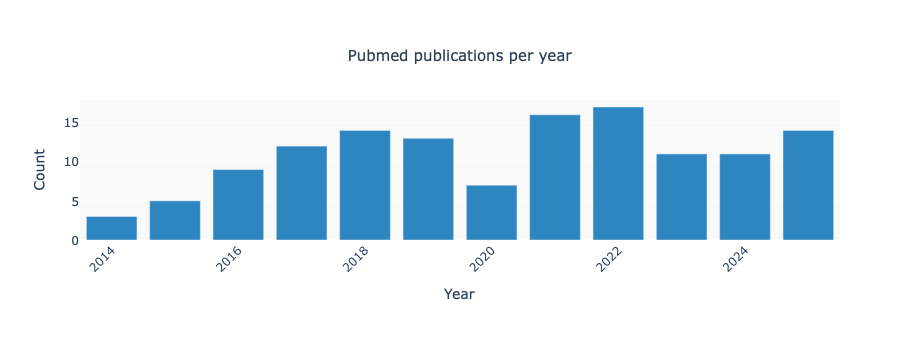

In [ ]:
fig_pm = go.Figure(data=[
    go.Bar(
        x=pm_year_count["datetime"],
        y=pm_year_count["count"],
        marker={"color": "#2E86C1"}
    )
])

fig_pm.update_layout(
    title={
        "text": "Pubmed publications per year",
        "x": 0.5,          # center title
        "xanchor": "center",
        "yanchor": "top",
        "font": {"size": 15, "color": "#2C3E50"}
    },
    xaxis={"title": "Year", "tickangle": -45},
    yaxis={"title": "Count"},
    plot_bgcolor="#f9f9f9",
    paper_bgcolor="#ffffff",
    margin={"b": 120}
)

In [ ]:
merged_dedup_df.loc[0]

id                                                              1
record_id                                                     222
title           Remote visualization of large-scale genomic al...
abstract        The Solve-RD project objectives include solvin...
journal                                             Cell genomics
source_id                                                36819661
doi                                    10.1016/j.xgen.2022.100246
status                                                  Published
publish_date                                  2023-01-11T00:00:00
link                    https://pubmed.ncbi.nlm.nih.gov/36819661/
authors         [{'id': 1, 'article_id': 1, 'name': 'Alberto C...
created_at                             2025-10-07T15:20:46.389778
created_by                                                deeptha
updated_at                             2025-10-07T15:20:46.389780
updated_by                                                deeptha
deleted_at

Deployment frequency: total number of commits per ?month or average across the top ?3. (Raw commit number should be avoided but here we are measuring activity/engagement rather than productivity).


In [ ]:
merged_dedup_df['authors'].loc[0]

[{'id': 1,
  'article_id': 1,
  'name': 'Alberto Corvò',
  'contact': None,
  'is_primary': True,
  'article_type': 'Article',
  'created_at': '2025-10-07T15:20:46.771662',
  'created_by': 'deeptha',
  'updated_at': '2025-10-07T15:20:46.771667',
  'updated_by': 'deeptha',
  'deleted_at': None,
  'deleted_by': None,
  'version': 1},
 {'id': 2,
  'article_id': 1,
  'name': 'Leslie Matalonga',
  'contact': None,
  'is_primary': False,
  'article_type': 'Article',
  'created_at': '2025-10-07T15:20:46.771683',
  'created_by': 'deeptha',
  'updated_at': '2025-10-07T15:20:46.771684',
  'updated_by': 'deeptha',
  'deleted_at': None,
  'deleted_by': None,
  'version': 1},
 {'id': 3,
  'article_id': 1,
  'name': 'Dylan Spalding',
  'contact': None,
  'is_primary': False,
  'article_type': 'Article',
  'created_at': '2025-10-07T15:20:46.771691',
  'created_by': 'deeptha',
  'updated_at': '2025-10-07T15:20:46.771691',
  'updated_by': 'deeptha',
  'deleted_at': None,
  'deleted_by': None,
  'versio

In [ ]:
merged_dedup_df['datetime'].dt.year

0      2023
1      2019
2      2025
3      2025
4      2025
       ... 
180    2016
181    2016
182    2016
186    2015
187    2014
Name: datetime, Length: 132, dtype: int32

In [ ]:
def get_articles_data(keyword):
    """
    Fetches article data from the API for a given keyword.

    What it does:
    - Sends a request to our analytics dashboard API
    - Returns a list of articles if successful
    - Returns an empty list if there's an error
    - Prints error messages to help with troubleshooting

    Parameters:
    - keyword: The search term (e.g., "GA4GH")

    Returns:
    - List of article dictionaries with all the metadata

    DO NOT MODIFY: This function is used throughout the analytics
    """
    url = f"{BASE_URL}/pubmed/articles/{keyword}"
    response = requests.get(url)

    if response.status_code == 200:
        return response.json()
    print(f"Error fetching data for {keyword}: {response.status_code}")
    return []

keywords = [
    "GA4GH",
    "Global Alliance for Genomics and Health"
]

all_articles_data = {}

print("Fetching articles data for analytics")
print()

for keyword in keywords:
    print(f"Searching for: {keyword}")
    articles = get_articles_data(keyword)
    all_articles_data[keyword] = articles
    print(f"Found {len(articles)} articles")
    print()

print("Data collection complete")

def analyze_journals(articles, keyword, top_n=10):
    """
    Analyzes journal distribution for a specific keyword's articles.

    What it does:
    - Counts how many articles appear in each journal
    - Identifies the top publishing venues
    - Creates a horizontal bar chart visualization
    - Shows which journals are most active in this topic

    DO NOT MODIFY ANYTHING HERE
    """
    journals = [article.get("journal", "Unknown") for article in articles if article.get("journal")]

    if not journals:
        print(f"No journal data found for {keyword}")
        return

    journal_counts = Counter(journals)
    top_journals = journal_counts.most_common(top_n)

    # Create horizontal bar chart with Plotly
    journals_list, counts_list = zip(*top_journals, strict=False)

    # Truncate long journal names for display
    display_journals = [journal[:50] + "" if len(journal) > 50 else journal for journal in journals_list]

    fig = go.Figure(go.Bar(
        x=counts_list,
        y=display_journals,
        orientation='h',
        marker_color='lightcoral',
        text=counts_list,
        textposition='outside'
    ))

    fig.update_layout(
        title=f"Top {top_n} Journals for {keyword} Articles",
        xaxis_title="Number of Publications",
        yaxis_title="Journals",
        height=max(400, len(top_journals) * 40),
        margin=dict(l=200)  # Left margin for journal names
    )

    fig.show()

    print(f"\nTop {top_n} journals for {keyword}:")
    for i, (journal, count) in enumerate(top_journals, 1):
        print(f"  {i}. {journal}: {count} articles")

print("Creating Journal Analysis for all keywords")
print("This shows which journals publish articles for each keyword.")
print()

# ✨ CUSTOMIZABLE: Change this number to show more/fewer top journals
top_journals_to_show = 8  # Shows top 8 journals for each keyword

journals_analyzed = 0

# Analyze journals for each keyword in your list
for keyword in keywords:
    articles = all_articles_data.get(keyword, [])

    if articles:
        print(f"Analyzing journals for: {keyword}")
        print("-" * 60)

        analyze_journals(articles, keyword, top_n=top_journals_to_show)
        journals_analyzed += 1

        print("\n" + "="*80 + "\n")
    else:
        print(f"No articles found for {keyword} - skipping journal analysis")
        print()

print(f"\nJournal Analysis Complete")
print(f"Analyzed journals for {journals_analyzed} out of {len(keywords)} keywords")
if journals_analyzed > 0:
    print("Use this data to:")
    print("   • Identify the leading journals in your keyword")
    print("   • Track which journals are most active in different topics")
    print("   • Discover interdisciplinary publication patterns")

Fetching articles data for analytics

Searching for: GA4GH
Found 91 articles

Searching for: Global Alliance for Genomics and Health
Found 97 articles

Data collection complete
Creating Journal Analysis for all keywords
This shows which journals publish articles for each keyword.

Analyzing journals for: GA4GH
------------------------------------------------------------



Top 8 journals for GA4GH:
  1. Cell genomics: 13 articles
  2. Nucleic acids research: 8 articles
  3. Human mutation: 7 articles
  4. Bioinformatics (Oxford, England): 6 articles
  5. medRxiv : the preprint server for health sciences: 4 articles
  6. F1000Research: 4 articles
  7. NPJ genomic medicine: 3 articles
  8. Human genomics: 2 articles


Analyzing journals for: Global Alliance for Genomics and Health
------------------------------------------------------------



Top 8 journals for Global Alliance for Genomics and Health:
  1. Cell genomics: 9 articles
  2. Bioinformatics (Oxford, England): 7 articles
  3. NPJ genomic medicine: 4 articles
  4. medRxiv : the preprint server for health sciences: 4 articles
  5. F1000Research: 4 articles
  6. Human mutation: 4 articles
  7. Genetics in medicine : official journal of the American College of Medical Genetics: 3 articles
  8. Human genomics: 3 articles



Journal Analysis Complete
Analyzed journals for 2 out of 2 keywords
Use this data to:
   • Identify the leading journals in your keyword
   • Track which journals are most active in different topics
   • Discover interdisciplinary publication patterns
